In [1]:
from quantum_function import *

# Entanglement of a pair of quantum emitters via Jz

### Ideal case $ \eta_1 = \eta_2 = 1$

In [5]:
def css_2(theta, phi):
    single_qubit = (np.sin(theta/2) * basis(2,0) + np.exp(1j*phi) * np.cos(theta/2) * basis(2,1))
    return tensor(single_qubit, single_qubit)

In [8]:
gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector


#my_initial_states = [piqs.css(2, x= np.pi/theta, basis = "uncoupled", coordinates="polar") for theta in [1,2,3,4,6]]
my_name_states = [f"css_theta_{theta}" for theta in [1,2,3,4,6]]

my_initial_states = [css_2(np.pi/theta,phi=0) for theta in [1,2,3,4,6]]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

#theo_curves = [
    #(1-np.exp(-gamma * times)),
    #(1-np.exp(-2*gamma * times)),
    #(1-np.exp(-2*gamma * times)),
    #(1-np.exp(-2*gamma * times)),
#]

ntraj = 1000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[concurrence_for_solver_general],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   8.07s. Est. time left: 00:00:01:12
20.0%. Run time:   9.01s. Est. time left: 00:00:00:36
30.0%. Run time:   9.84s. Est. time left: 00:00:00:22
40.0%. Run time:  10.67s. Est. time left: 00:00:00:15
50.0%. Run time:  11.51s. Est. time left: 00:00:00:11
60.0%. Run time:  12.37s. Est. time left: 00:00:00:08
70.0%. Run time:  13.22s. Est. time left: 00:00:00:05
80.0%. Run time:  14.07s. Est. time left: 00:00:00:03
90.0%. Run time:  14.93s. Est. time left: 00:00:00:01
100.0%. Run time:  15.77s. Est. time left: 00:00:00:00
Total run time:  16.74s
10.0%. Run time:   7.83s. Est. time left: 00:00:01:10
20.0%. Run time:   8.73s. Est. time left: 00:00:00:34
30.0%. Run time:   9.66s. Est. time left: 00:00:00:22
40.0%. Run time:  10.76s. Est. time left: 00:00:00:16
50.0%. Run time:  11.79s. Est. time left: 00:00:00:11
60.0%. Run time:  12.85s. Est. time left: 00:00:00:08
70.0%. Run time:  13.95s. Est. time left: 00:00:00:05
80.0%. Run time:  15.10s. Est. time left: 00:00:00:03
90.

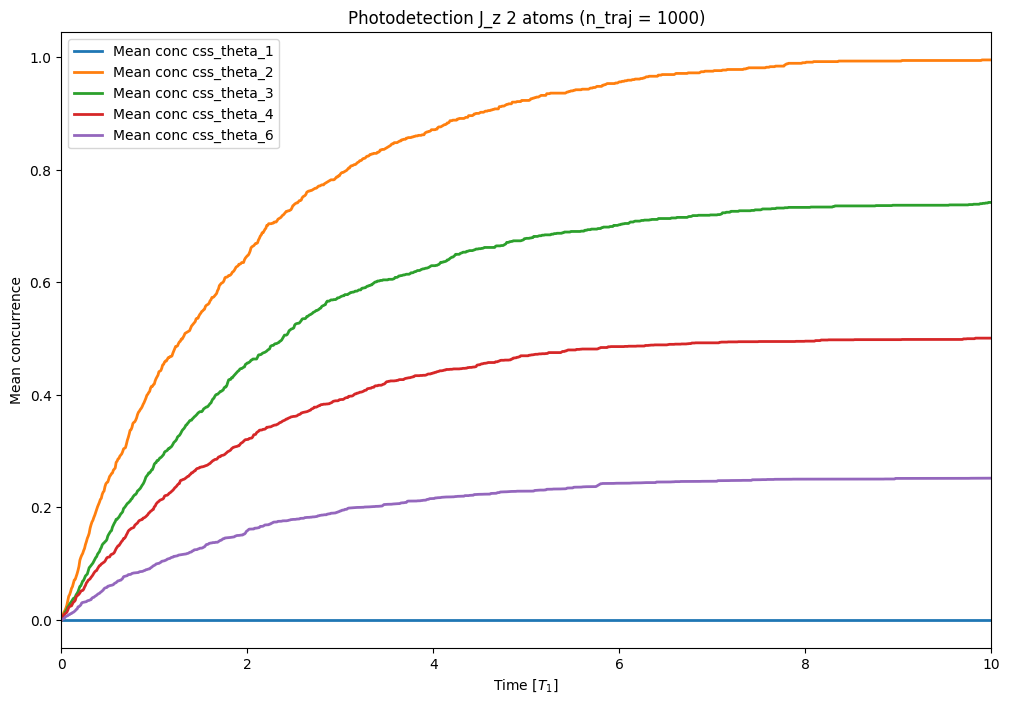

In [12]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

In [13]:
gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector


my_name_states = ["ee","psi_plus","phi_plus"]

my_initial_states = [ee, psi_plus, phi_plus]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[concurrence_for_solver_general],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   8.76s. Est. time left: 00:00:01:18
20.0%. Run time:   9.19s. Est. time left: 00:00:00:36
30.0%. Run time:   9.72s. Est. time left: 00:00:00:22
40.0%. Run time:  10.12s. Est. time left: 00:00:00:15
50.0%. Run time:  10.54s. Est. time left: 00:00:00:10
60.0%. Run time:  10.96s. Est. time left: 00:00:00:07
70.0%. Run time:  11.40s. Est. time left: 00:00:00:04
80.0%. Run time:  11.89s. Est. time left: 00:00:00:02
90.0%. Run time:  12.34s. Est. time left: 00:00:00:01
100.0%. Run time:  12.71s. Est. time left: 00:00:00:00
Total run time:  13.96s
10.0%. Run time:   8.25s. Est. time left: 00:00:01:14
20.0%. Run time:   8.74s. Est. time left: 00:00:00:34
30.0%. Run time:   9.19s. Est. time left: 00:00:00:21
40.0%. Run time:   9.70s. Est. time left: 00:00:00:14
50.0%. Run time:  10.26s. Est. time left: 00:00:00:10
60.0%. Run time:  10.76s. Est. time left: 00:00:00:07
70.0%. Run time:  11.19s. Est. time left: 00:00:00:04
80.0%. Run time:  11.66s. Est. time left: 00:00:00:02
90.

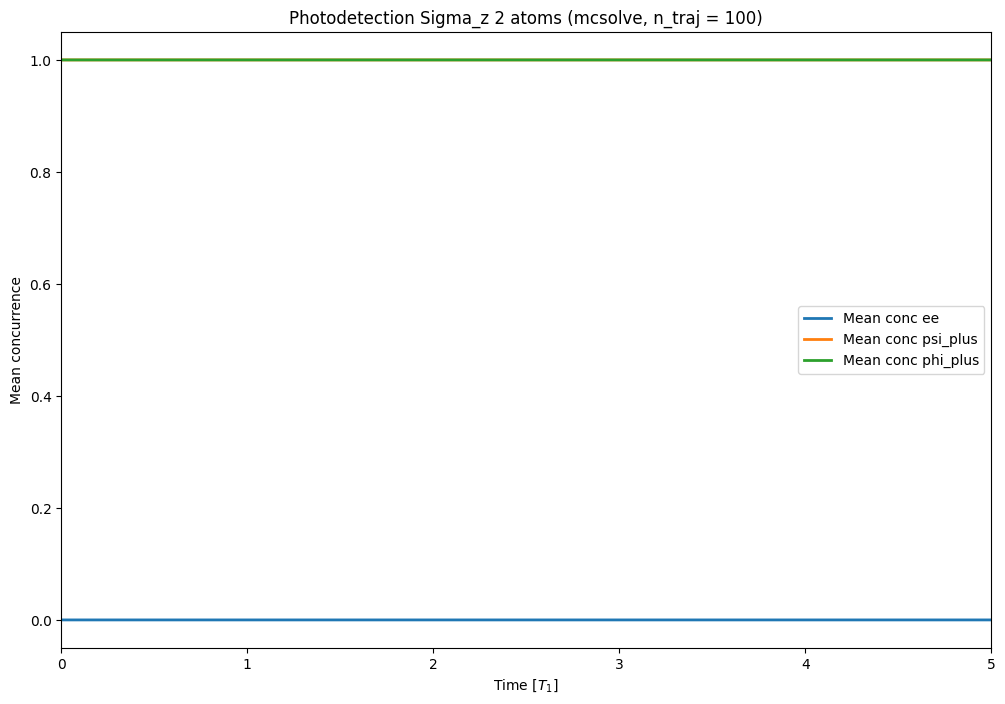

In [14]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 5)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Photodetection Sigma_z 2 atoms (mcsolve, n_traj = {ntraj})")
plt.legend()
plt.show()

## Css states

$|\theta, \phi\rangle = \bigotimes_{i=1}^N \left( \cos\frac{\theta}{2}\,|0\rangle_i + e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle_i \right)$

x=theta se uso coordinate polari

In [ ]:
def css_2(theta, phi):
    if theta == np.pi: #State |11>
        return tensor(basis(2,0), basis(2,0))
    
    elif theta == 0: #State |00>
        return tensor(basis(2,1), basis(2,1))
    
    single_qubit = (np.sin(theta/2) * basis(2,0) + np.exp(1j*phi) * np.cos(theta/2) * basis(2,1))
    return tensor(single_qubit, single_qubit)

css_2(np.pi/2, 0)

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector

my_name_states = [f"css_theta=pi/{angle}" for angle in [1,2,3,4,6]]
#my_initial_states = [css_2(theta=np.pi/angle, phi=0) for angle in [1,2,3,4,6]] 

#Now I have to use the css from piqs because I need the density matrix
#my_initial_states = [piqs.css(2, x= np.pi/theta, basis = "uncoupled", coordinates="polar") for theta in [1,2,3,4,6]] #|11>, |++>, ..., ..., ..., 

my_eta = [1, 0.9, 0.7, 0.5] # detection efficiency

#Dict of dataframe for each initial state
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for eta in my_eta:
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*eta / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(gamma*eta / 2) * (sigma_z_1 - sigma_z_2)
        ],

        sc_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (sigma_minus_1),
        np.sqrt(gamma*(1-eta) / 2) * (sigma_minus_2)
        ],

        e_ops=[concurrence_for_solver_general],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


In [35]:
(sigma_z_1+sigma_z_2)*(sigma_z_1+sigma_z_2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[4. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 4.]]

# Spin squeezing

In [ ]:
#=================================================================================================================================
# //-- SPIN SQUEEZING --// =======================================================================================================
#=================================================================================================================================

J_x = 0.5 * (tensor(sigmax(), I_2) + tensor(I_2, sigmax()))
J_y = 0.5 * (tensor(sigmay(), I_2) + tensor(I_2, sigmay()))
J_z = 0.5 * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz())) 

def eval_J_norm(state):
    return np.sqrt(expect(J_x, state)**2 + expect(J_y, state)**2 + expect(J_z, state)**2)

def compute_spin_squeezing_angles(rho):
    """Calcola θ e φ a partire dai valori medi di J"""
    
    # valori medi
    Jx_exp, Jy_exp, Jz_exp = [expect(J, rho) for J in (J_x, J_y, J_z)]

    J_norm = eval_J_norm(rho)

    if J_norm < 1e-12:
        raise ValueError("Il vettore di spin medio è nullo, θ e φ non sono ben definiti.")
    
    # theta
    theta = np.arccos(Jz_exp / J_norm)
    
    # phi
    if abs(np.sin(theta)) < 1e-12:
        phi = 0.0   # convenzione arbitraria sull'asse z
    else:
        cosphi = Jx_exp / (J_norm * np.sin(theta))
        cosphi = np.clip(cosphi, -1.0, 1.0)  # stabilità numerica
        if Jy_exp > 0:
            phi = np.arccos(cosphi)
        else:
            phi = 2*np.pi - np.arccos(cosphi)
    
    return theta, phi

def Jn1_Jn_2(rho, theta, phi):
    """Calcola J_n1 e J_n2 a partire da θ e φ"""
    
    # versori
    n1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
    n2 = np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
    
    # operatori
    Jn1 = n1[0]*J_x + n1[1]*J_y + n1[2]*J_z
    Jn2 = n2[0]*J_x + n2[1]*J_y + n2[2]*J_z
    
    return Jn1, Jn2

def spin_squeezing_KU(rho, N):
    """Calcola il parametro di spin squeezing secondo Kitagawa-Ueda"""
    
    # calcolo θ e φ
    theta, phi = compute_spin_squeezing_angles(rho)
    
    # calcolo J_n1 e J_n2
    Jn1, Jn2 = Jn1_Jn_2(rho, theta, phi)
    
    #xi_sq = (2/N)*(expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))/eval_J_norm(rho) by autocompletion
    xi_sq = (2/N)*(expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))
    return np.clip(xi_sq,0,1) # clip to avoid numerical issues

In [ ]:
some_spin_squeezing = [spin_squeezing_KU(css_2(np.pi/theta, 0),2) for theta in [1,2,3,4,6]]
some_spin_squeezing

#SEMBRA WORKARE

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9999999999999999),
 np.float64(1.0)]